## Classification
With some regression models run to determine the best NBA scorers, we will now classify players based on their playstyle. This should help to show us how impactful players make their impacts on the game. Not everything can be measured in points and rebounds when it comes to winning basketball games.

In [204]:
# imports - make sure these are present in the top of our final submission
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# read data
player_basic = pd.read_csv(
	r"C:\\Users\\zachr\\OneDrive - Wilfrid Laurier University\\player_basic.csv",
	encoding="latin1"
)
player_advanced = pd.read_csv(
	r"C:\\Users\\zachr\\OneDrive - Wilfrid Laurier University\\player_advanced.csv",
	encoding="latin1"
)


In [205]:
player_stats = pd.merge(player_basic, player_advanced, on=["Player", "Team"], how="inner")
player_stats.drop(columns=[col for col in player_stats.columns if col.endswith('_y')], inplace=True)
player_stats.rename(columns={col: col[:-2] for col in player_stats.columns if col.endswith('_x')}, inplace=True)
player_stats.drop(columns=["Rk", "Player-additional"], inplace=True)

## Logistic Regression

We will start by using logistic regression to predict player positions using different types of statistics.

              precision    recall  f1-score   support

           0       0.73      0.89      0.80        64
           1       0.87      0.69      0.77        68

    accuracy                           0.79       132
   macro avg       0.80      0.79      0.79       132
weighted avg       0.80      0.79      0.79       132

[[57  7]
 [21 47]]


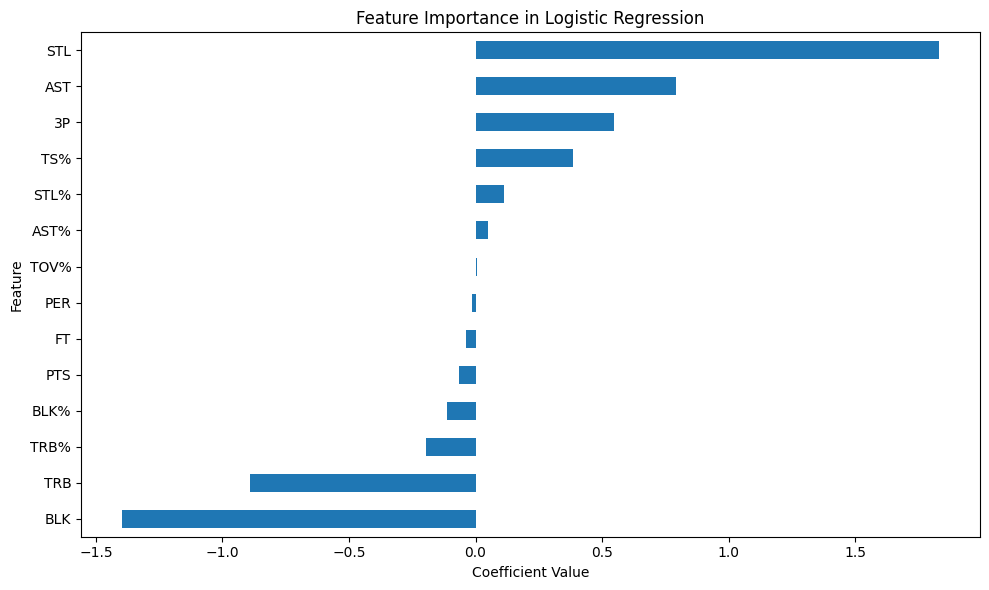

            Player Pos predicted_position
22    LeBron James  SF              Guard
25    Franz Wagner  SF              Guard
35     Zach LaVine  SF              Guard
40   DeMar DeRozan  SF              Guard
41  Brandon Ingram  SF              Guard


In [206]:

player_model = player_stats[(player_stats["Player"] != "League Average") & (player_stats["Team"] != "2TM")].copy()

# create target variable: 1 if guard, 0 if big
player_model["is_guard"] = player_model["Pos"].astype(str).str.contains("G", na=False).astype(int)

# select features and target
features = [
    "PTS",
    "AST",
    "TRB",
    "STL",
    "BLK",
    "3P",
    "FT",
    "PER",
    "TS%",
    "TRB%",
    "AST%",
    "STL%",
    "BLK%",
    "TOV%",
]
X = player_model[features].fillna(player_model[features].median())
y = player_model["is_guard"]
# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# make predictions and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# visualize feature importance
feature_importance = pd.Series(model.coef_[0], index=features).sort_values()
plt.figure(figsize=(10, 6))
feature_importance.plot(kind="barh")
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# add predicted position label to original dataframe

player_model["predicted_position"] = np.where(
    model.predict(X) == 1, "Guard", "Big"
)
# display mislabelled players (misclassified by the model)

mislabelled_players = player_model[player_model["Pos"].str.contains("G") & (player_model["predicted_position"] == "Big") | player_model["Pos"].str.contains("F|C") & (player_model["predicted_position"] == "Guard")]
print(mislabelled_players[["Player", "Pos", "predicted_position"]].head(5))



### Logistic Regression (Hybrid Stats)

When using a combination of basic and advanced statistics, we can see that the most frequent misclassification is high-scoring wing players as guards, particularly if they shoot the ball well from three-point range. The feature importance explains this to a degree, as volume steals, assists and 3 pointers take on a larger feature importance.

### Logistic Regression (Basic Stats)

=== Player Basic Stats Model ===
              precision    recall  f1-score   support

           0       0.73      0.89      0.80        64
           1       0.87      0.69      0.77        68

    accuracy                           0.79       132
   macro avg       0.80      0.79      0.79       132
weighted avg       0.80      0.79      0.79       132

[[57  7]
 [21 47]]


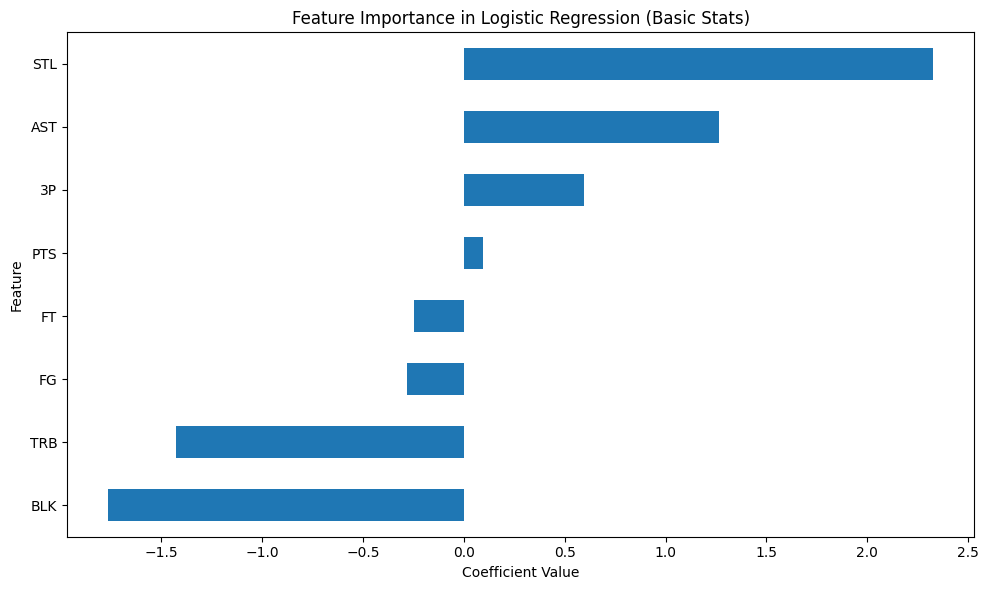

            Player Pos predicted_position
22    LeBron James  SF              Guard
25    Franz Wagner  SF              Guard
35     Zach LaVine  SF              Guard
40   DeMar DeRozan  SF              Guard
41  Brandon Ingram  SF              Guard


In [207]:
# Logistic Regression on player_basic dataset
player_model_basic = player_basic[(player_basic["Player"] != "League Average") & (player_basic["Team"] != "2TM")].copy()

# create target variable: 1 if guard, 0 if big
player_model_basic["is_guard"] = player_model_basic["Pos"].astype(str).str.contains("G", na=False).astype(int)

# select features and target (basic stats)
features_basic = [
    "PTS",
    "AST",
    "TRB",
    "STL",
    "BLK",
    "3P",
    "FT",
    "FG",
]
X_basic = player_model_basic[features_basic].fillna(player_model_basic[features_basic].median())
y_basic = player_model_basic["is_guard"]

# split data into train and test sets
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(
    X_basic, y_basic, test_size=0.2, random_state=42
)

# fit logistic regression model
model_basic = LogisticRegression(max_iter=1000)
model_basic.fit(X_train_basic, y_train_basic)

# make predictions and evaluate
y_pred_basic = model_basic.predict(X_test_basic)
print("=== Player Basic Stats Model ===")
print(classification_report(y_test_basic, y_pred_basic))
print(confusion_matrix(y_test_basic, y_pred_basic))

# visualize feature importance
feature_importance_basic = pd.Series(model_basic.coef_[0], index=features_basic).sort_values()
plt.figure(figsize=(10, 6))
feature_importance_basic.plot(kind="barh")
plt.title("Feature Importance in Logistic Regression (Basic Stats)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# add predicted position label to original dataframe
player_model_basic["predicted_position"] = np.where(
    model_basic.predict(X_basic) == 1, "Guard", "Big"
)

# display mislabelled players (misclassified by the model)
mislabelled_players_basic = player_model_basic[player_model_basic["Pos"].str.contains("G") & (player_model_basic["predicted_position"] == "Big") | player_model_basic["Pos"].str.contains("F|C") & (player_model_basic["predicted_position"] == "Guard")]
print(mislabelled_players_basic[["Player", "Pos", "predicted_position"]].head(5))

### Logistic Regression (Advanced Stats)

=== Player Advanced Stats Model ===
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        72
           1       0.81      0.87      0.84        60

    accuracy                           0.85       132
   macro avg       0.85      0.85      0.85       132
weighted avg       0.85      0.85      0.85       132

[[60 12]
 [ 8 52]]


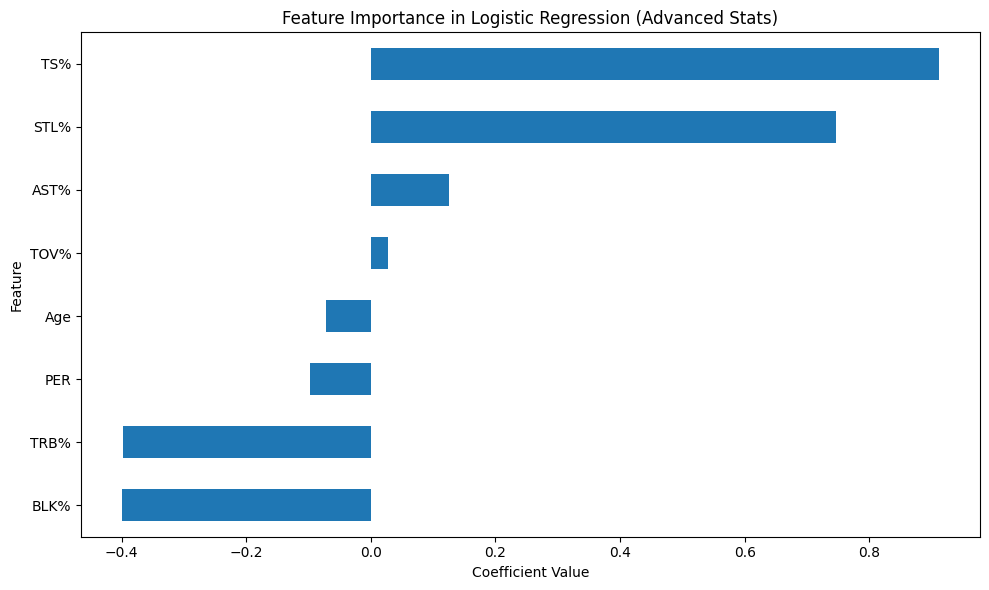

             Player Pos predicted_position
0     Mikal Bridges  SF              Guard
1         Josh Hart  SG                Big
5     DeMar DeRozan  SF              Guard
10  Christian Braun  SG                Big
17      Zach LaVine  SF              Guard


In [208]:
# Logistic Regression on player_advanced dataset
player_model_adv = player_advanced[(player_advanced["Player"] != "League Average") & (player_advanced["Team"] != "2TM")].copy()

# create target variable: 1 if guard, 0 if big
player_model_adv["is_guard"] = player_model_adv["Pos"].astype(str).str.contains("G", na=False).astype(int)

# select features and target (advanced stats)
features_adv = [
    "Age",
    "PER",
    "TS%",
    "TRB%",
    "AST%",
    "STL%",
    "BLK%",
    "TOV%",
]
X_adv = player_model_adv[features_adv].fillna(player_model_adv[features_adv].median())
y_adv = player_model_adv["is_guard"]

# split data into train and test sets
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv, test_size=0.2, random_state=42
)

# fit logistic regression model
model_adv = LogisticRegression(max_iter=1000)
model_adv.fit(X_train_adv, y_train_adv)

# make predictions and evaluate
y_pred_adv = model_adv.predict(X_test_adv)
print("=== Player Advanced Stats Model ===")
print(classification_report(y_test_adv, y_pred_adv))
print(confusion_matrix(y_test_adv, y_pred_adv))

# visualize feature importance
feature_importance_adv = pd.Series(model_adv.coef_[0], index=features_adv).sort_values()
plt.figure(figsize=(10, 6))
feature_importance_adv.plot(kind="barh")
plt.title("Feature Importance in Logistic Regression (Advanced Stats)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# add predicted position label to original dataframe
player_model_adv["predicted_position"] = np.where(
    model_adv.predict(X_adv) == 1, "Guard", "Big"
)

# display mislabelled players (misclassified by the model)
mislabelled_players_adv = player_model_adv[player_model_adv["Pos"].str.contains("G") & (player_model_adv["predicted_position"] == "Big") | player_model_adv["Pos"].str.contains("F|C") & (player_model_adv["predicted_position"] == "Guard")]
print(mislabelled_players_adv[["Player", "Pos", "predicted_position"]].head(5))

The logistic regression model left us with a few results to interpret.

First, we can see that the bias towards the volume features shown in the feature importance plot reduces the effectiveness of the hybrid model, especially since the basic statistics are less accurate than the advanced in this particular task. Since percentages cannot go over 1 as a rule, their coefficients are weighted less than their basic stat counterparts. This is further proven by the fact that the same five players are misclassified in the basic and hybrid models. 

The advanced model has an accuracy of around 85%, compared to below 80% for the other two models. This is somewhat intuitive, but has now been confirmed through modelling. The best measures of positional playstyle are tendencies, rather than volume statistics.

## Hierarchical Clustering

Next, we will use hierarchical clustering to group players by their statistical profiles without predefined position labels.

### Hierarchical Clustering (Hybrid Stats)

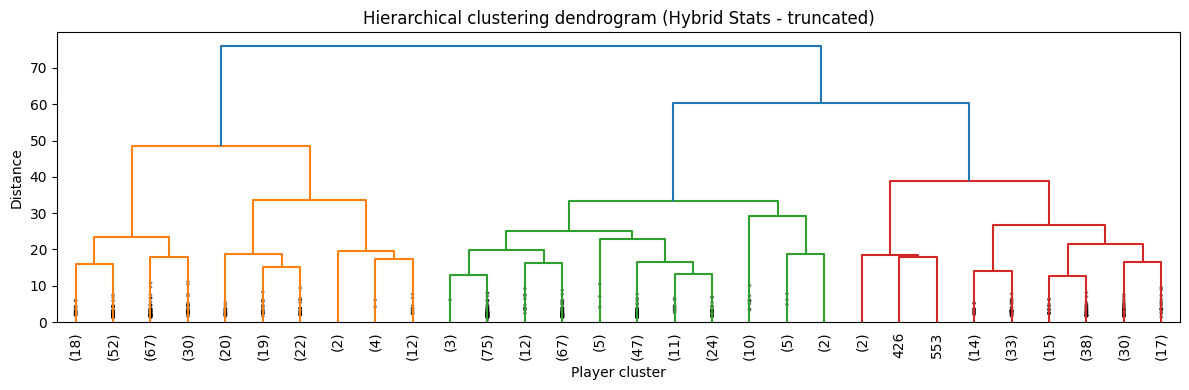

n_clusters=4; unique clusters=4
silhouette score: 0.116
cluster
0    151
1     79
2    261
3    167
Name: count, dtype: int64

Cluster 0 players:
              Player Team Pos
64      John Collins  UTA  PF
106    Mark Williams  CHO   C
114  P.J. Washington  DAL  PF
119     Jakob Poeltl  TOR   C
120    Deandre Ayton  POR   C
130       Tolu Smith  DET  PF
132     Bobby Portis  MIL  PF
136   Onyeka Okongwu  ATL   C
145        Alex Sarr  WAS   C
146    Moritz Wagner  ORL   C

Cluster 0 mean stats:
PER      12.139855
TS%       0.537746
3PAr      0.427609
FTr       0.242826
ORB%      6.284783
DRB%     15.007246
TRB%     10.622464
AST%     12.991304
STL%      1.775362
BLK%      2.107246
TOV%     13.000000
USG%     15.970290
OWS       0.498551
DWS       0.628986
WS        1.128986
WS/48     0.075312
OBPM     -2.101449
DBPM      0.068841
BPM      -2.034783
VORP      0.125362
PTS       5.834783
AST       1.514493
TRB       3.037681
STL       0.573913
BLK       0.357971
3P        0.751449
FT     

In [209]:
# Hierarchical Clustering on player_stats (hybrid) dataset
numeric_cols = [
    'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%',
    'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS',
    'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', "PTS",
    "AST", "TRB", "STL", "BLK", "3P", "FT",
]

df_players = player_stats[(player_stats['Player'] != 'League Average') & (player_stats['Team'] != '2TM')].copy()
X_raw = df_players[numeric_cols]
X_clean = X_raw.fillna(X_raw.median())

scaler = StandardScaler()
X = scaler.fit_transform(X_clean)

Z = linkage(X, method='ward')
plt.figure(figsize=(12, 4))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical clustering dendrogram (Hybrid Stats - truncated)')
plt.xlabel('Player cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

def cluster_players(n_clusters=4):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    clustered = df_players[['Player', 'Team', 'Pos']].copy()
    clustered['cluster'] = labels
    print(f'n_clusters={n_clusters}; unique clusters={len(np.unique(labels))}')
    if len(np.unique(labels)) > 1:
        print('silhouette score:', round(silhouette_score(X, labels), 3))
    print(clustered.groupby('cluster').size().rename('count'))
    return clustered

clustered_players = cluster_players(4)
cluster_means = pd.concat([X_clean.reset_index(drop=True), clustered_players['cluster']], axis=1).groupby('cluster').mean()

# Display 10 players for each cluster, along with mean stats for each cluster
for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(clustered_players[clustered_players['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means.loc[cluster])

### Hierarchical Clustering (Basic Stats)

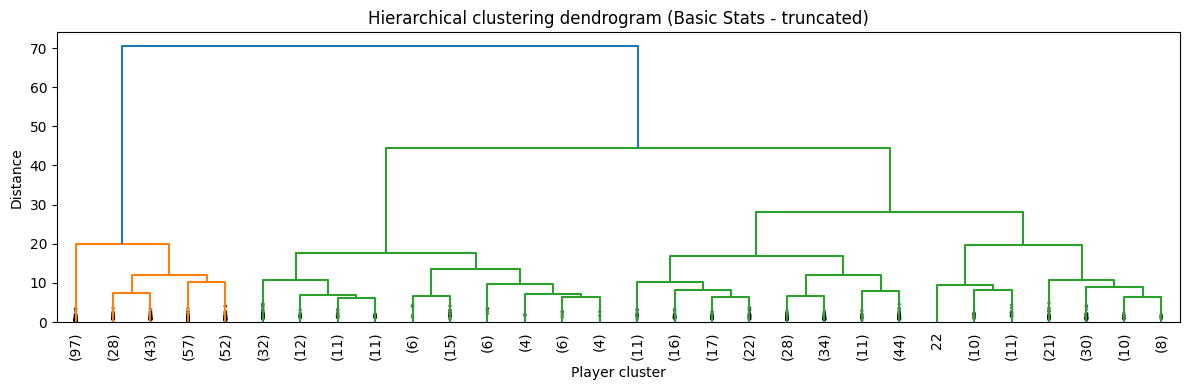

n_clusters=4; unique clusters=4
silhouette score: 0.289
cluster
0    277
1     91
2    107
3    183
Name: count, dtype: int64

Cluster 0 players:
               Player Team Pos
258       A.J. Lawson  TOR  SG
263      Jared Butler  WAS  PG
283      Kelly Olynyk  TOR   C
291       DantÃ© Exum  DAL  PG
293       Jaden Hardy  DAL  SG
302      Jared Rhoden  CHO  SG
304     Jaylen Nowell  NOP  SG
307       Bruce Brown  TOR  PG
312  Brandon Williams  DAL  PG
323      Caleb Martin  DAL  SF

Cluster 0 mean stats:
PTS     3.373786
AST     1.027184
TRB     2.009709
STL     0.404854
BLK     0.239806
3P      0.436408
FT      0.410194
FG      1.267961
MP     10.668932
G      26.320388
Name: 0.0, dtype: float64

Cluster 1 players:
                   Player Team Pos
18          Anthony Davis  DAL  PF
24      Victor Wembanyama  SAS   C
42      Jaren Jackson Jr.  MEM   C
58   Kristaps PorziÅÄ£is  BOS   C
64           John Collins  UTA  PF
70            Evan Mobley  CLE  PF
94            Ivica Zubac  LA

In [210]:
# Hierarchical Clustering on player_basic dataset
numeric_cols_basic = [
    "PTS", "AST", "TRB", "STL", "BLK", "3P", "FT", "FG",
    "MP", "G"
]

df_players_basic = player_basic[(player_basic['Player'] != 'League Average') & (player_basic['Team'] != '2TM')].copy()
X_raw_basic = df_players_basic[numeric_cols_basic]
X_clean_basic = X_raw_basic.fillna(X_raw_basic.median())

scaler_basic = StandardScaler()
X_basic_scaled = scaler_basic.fit_transform(X_clean_basic)

Z_basic = linkage(X_basic_scaled, method='ward')
plt.figure(figsize=(12, 4))
dendrogram(
    Z_basic,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical clustering dendrogram (Basic Stats - truncated)')
plt.xlabel('Player cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

def cluster_players_basic(n_clusters=4):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_basic_scaled)
    clustered = df_players_basic[['Player', 'Team', 'Pos']].copy()
    clustered['cluster'] = labels
    print(f'n_clusters={n_clusters}; unique clusters={len(np.unique(labels))}')
    if len(np.unique(labels)) > 1:
        print('silhouette score:', round(silhouette_score(X_basic_scaled, labels), 3))
    print(clustered.groupby('cluster').size().rename('count'))
    return clustered

clustered_players_basic = cluster_players_basic(4)
cluster_means_basic = pd.concat([X_clean_basic.reset_index(drop=True), clustered_players_basic['cluster']], axis=1).groupby('cluster').mean()

# Display 10 players for each cluster, along with mean stats for each cluster
for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(clustered_players_basic[clustered_players_basic['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_basic.loc[cluster])

### Hierarchical Clustering (Advanced Stats)

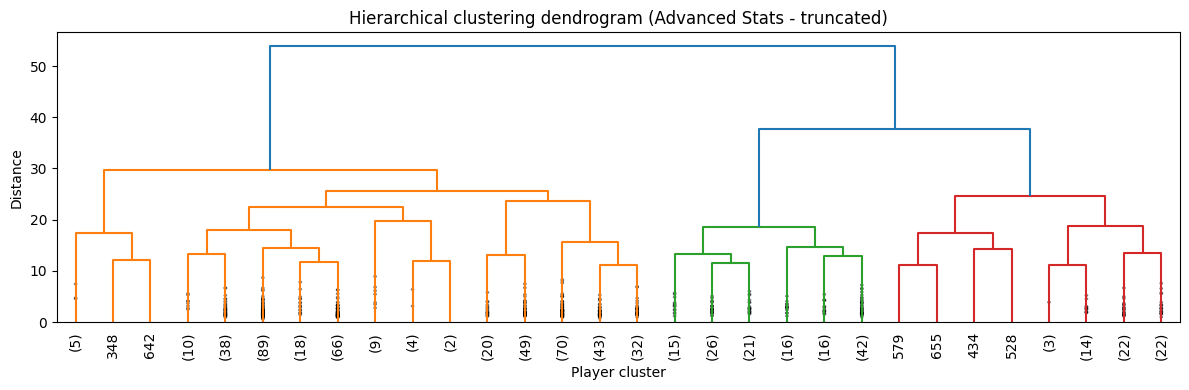

n_clusters=4; unique clusters=4
silhouette score: 0.214
cluster
0    450
1     65
2    136
3      7
Name: count, dtype: int64

Cluster 0 players:
                Player Team Pos
0        Mikal Bridges  NYK  SF
8           OG Anunoby  NYK  PF
10     Christian Braun  DEN  SG
14     Jaden McDaniels  MIN  PF
15       Keegan Murray  SAC  PF
17         Zach LaVine  CHI  SF
18         Zach LaVine  SAC  SG
20  Michael Porter Jr.  DEN  SF
21       Derrick White  BOS  SG
22       Dyson Daniels  ATL  SG

Cluster 0 mean stats:
PER     13.047716
TS%      0.551909
3PAr     0.424854
FTr      0.245853
ORB%     5.671320
DRB%    14.641624
TRB%    10.146447
AST%    14.268782
STL%     1.653807
BLK%     1.882487
TOV%    12.533756
USG%    18.311421
OWS      0.955330
DWS      0.891371
Age     25.847716
Name: 0.0, dtype: float64

Cluster 1 players:
             Player Team Pos
1         Josh Hart  NYK  SG
2   Anthony Edwards  MIN  SG
3      Devin Booker  PHO  SG
4      James Harden  LAC  PG
5     DeMar DeRoza

In [211]:
# Hierarchical Clustering on player_advanced dataset
numeric_cols_adv = [
    'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%',
    'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'Age'
]

df_players_adv = player_advanced[(player_advanced['Player'] != 'League Average') & (player_advanced['Team'] != '2TM')].copy()
X_raw_adv = df_players_adv[numeric_cols_adv]
X_clean_adv = X_raw_adv.fillna(X_raw_adv.median())

scaler_adv = StandardScaler()
X_adv_scaled = scaler_adv.fit_transform(X_clean_adv)

Z_adv = linkage(X_adv_scaled, method='ward')
plt.figure(figsize=(12, 4))
dendrogram(
    Z_adv,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical clustering dendrogram (Advanced Stats - truncated)')
plt.xlabel('Player cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

def cluster_players_adv(n_clusters=4):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_adv_scaled)
    clustered = df_players_adv[['Player', 'Team', 'Pos']].copy()
    clustered['cluster'] = labels
    print(f'n_clusters={n_clusters}; unique clusters={len(np.unique(labels))}')
    if len(np.unique(labels)) > 1:
        print('silhouette score:', round(silhouette_score(X_adv_scaled, labels), 3))
    print(clustered.groupby('cluster').size().rename('count'))
    return clustered

clustered_players_adv = cluster_players_adv(4)
cluster_means_adv = pd.concat([X_clean_adv.reset_index(drop=True), clustered_players_adv['cluster']], axis=1).groupby('cluster').mean()

# Display 10 players for each cluster, along with mean stats for each cluster
for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(clustered_players_adv[clustered_players_adv['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_adv.loc[cluster])

The hierarchal clustering shows 

## K-Means Clustering

Finally, we will use K-means clustering to create more refined player groupings with a fixed number of clusters.

### K-means Clustering (Hybrid Stats)

cluster
0    145
1    129
2    290
3     94
Name: count, dtype: int64
silhouette score: 0.16

Cluster 0 players:
             Player Team Pos
167      Drew Timme  BRK  PF
233  Nick Smith Jr.  CHO  SG
288  Oshae Brissett  PHI  SF
302    Jared Rhoden  CHO  SG
304   Jaylen Nowell  NOP  SG
323    Caleb Martin  DAL  SF
324   Tyson Etienne  BRK  PG
326      KJ Simpson  CHO  PG
332      AJ Johnson  MIL  SG
333      AJ Johnson  WAS  SG

Cluster 0 mean stats:
PER       6.203448
TS%       0.415119
3PAr      0.460832
FTr       0.242888
ORB%      5.085517
DRB%     13.170345
TRB%      9.142759
AST%     12.162759
STL%      1.650345
BLK%      1.200690
TOV%     15.295833
USG%     16.732414
OWS      -0.138621
DWS       0.157241
WS        0.021379
WS/48    -0.032572
OBPM     -5.824138
DBPM     -1.138621
BPM      -6.959310
VORP     -0.163448
PTS       2.867586
AST       0.943448
TRB       1.637241
STL       0.324828
BLK       0.134483
3P        0.354483
FT        0.395862
Name: 0, dtype: float64

Cluster

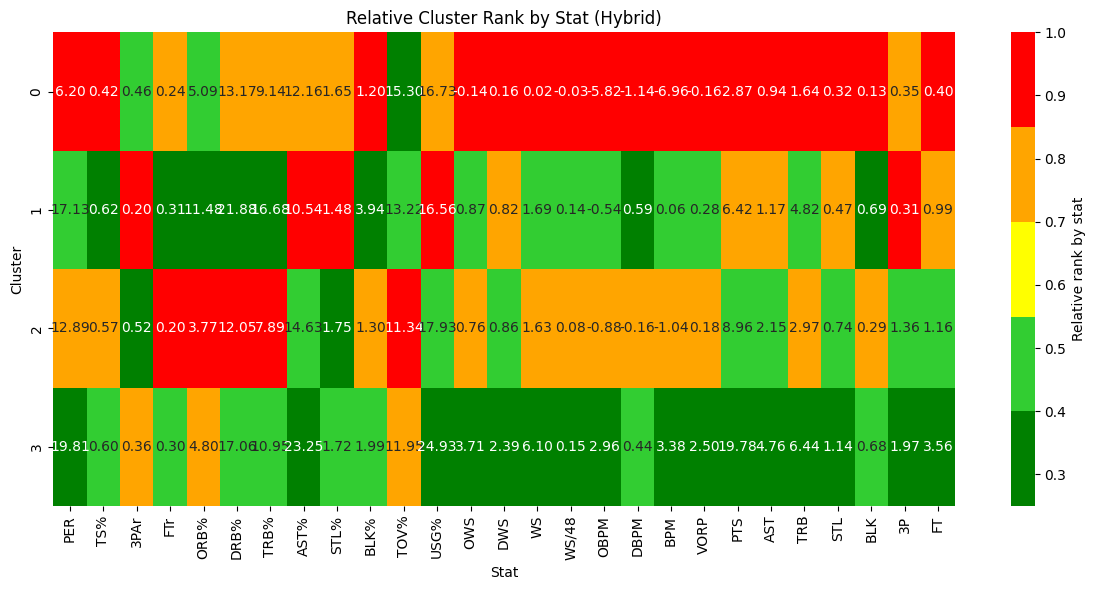

,Player,Team,Pos,cluster,predicted_position
332,AJ Johnson,MIL,SG,0,Guard
333,AJ Johnson,WAS,SG,0,Guard
323,Caleb Martin,DAL,SF,0,Guard
167,Drew Timme,BRK,PF,0,Big
302,Jared Rhoden,CHO,SG,0,Big
304,Jaylen Nowell,NOP,SG,0,Big
326,KJ Simpson,CHO,PG,0,Guard
233,Nick Smith Jr.,CHO,SG,0,Guard
288,Oshae Brissett,PHI,SF,0,Big
324,Tyson Etienne,BRK,PG,0,Guard


In [212]:
# K-means Clustering on player_stats (hybrid) dataset
from matplotlib.colors import ListedColormap

qualified_players = player_model.copy()
qualified_features = qualified_players[numeric_cols].fillna(qualified_players[numeric_cols].median())
qualified_scaled = scaler.fit_transform(qualified_features)

kmeans_hybrid = KMeans(n_clusters=4, random_state=42, n_init=10)
qualified_players["cluster"] = kmeans_hybrid.fit_predict(qualified_scaled)

print(qualified_players["cluster"].value_counts().sort_index())
print("silhouette score:", round(silhouette_score(qualified_scaled, qualified_players["cluster"]), 3))

cluster_means_hybrid = (
    pd.concat(
        [qualified_players[numeric_cols].reset_index(drop=True), qualified_players["cluster"].reset_index(drop=True)],
        axis=1,
    )
    .groupby("cluster")
    .mean()
)

# Display 10 players for each cluster, along with mean stats for each cluster
for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(qualified_players[qualified_players['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_hybrid.loc[cluster])

# Display feature importance for KMeans clusters using heatmap,
# with colors scaled relative to each stat column
ranked_hybrid = cluster_means_hybrid.rank(axis=0, method="average", ascending=False)
ranked_norm_hybrid = ranked_hybrid / ranked_hybrid.max()

plt.figure(figsize=(12, 6))
rank_colors = ListedColormap(["green", "limegreen", "yellow", "orange", "red"])
sns.heatmap(
    ranked_norm_hybrid,
    annot=cluster_means_hybrid.round(2),
    fmt=".2f",
    cmap=rank_colors,
    cbar_kws={"label": "Relative rank by stat"}
)
plt.title("Relative Cluster Rank by Stat (Hybrid)")
plt.xlabel("Stat")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# Create a dataframe of the top 10 players per cluster with their cluster and predicted position
top_players_per_cluster = qualified_players.groupby('cluster').head(10)[['Player', 'Team', 'Pos', 'cluster', 'predicted_position']].sort_values(by=['cluster', 'Player'])
top_players_per_cluster

### K-means Clustering (Basic Stats)

cluster
0     78
1    223
2    259
3     98
Name: count, dtype: int64
silhouette score: 0.308

Cluster 0 players:
              Player Team Pos
18     Anthony Davis  DAL  PF
70       Evan Mobley  CLE  PF
94       Ivica Zubac  LAC   C
102     Myles Turner  IND   C
106    Mark Williams  CHO   C
108    Chet Holmgren  OKC   C
114  P.J. Washington  DAL  PF
119     Jakob Poeltl  TOR   C
120    Deandre Ayton  POR   C
124         Naz Reid  MIN   C

Cluster 0 mean stats:
PTS     9.888462
AST     1.729487
TRB     7.070513
STL     0.725641
BLK     1.039744
3P      0.470513
FT      1.508974
FG      3.960256
MP     23.317949
G      50.064103
Name: 0, dtype: float64

Cluster 1 players:
               Player Team Pos
90    De'Andre Hunter  CLE  SF
96      Malik Beasley  DET  SG
98    Jordan Clarkson  UTA  SG
104  Jonathan Kuminga  GSW  PF
105      Jared McCain  PHI  SG
110        Kyle Kuzma  WAS  PF
111        Kyle Kuzma  MIL  PF
112    Stephon Castle  SAS  SG
113      Aaron Gordon  DEN  PF
116    Qu

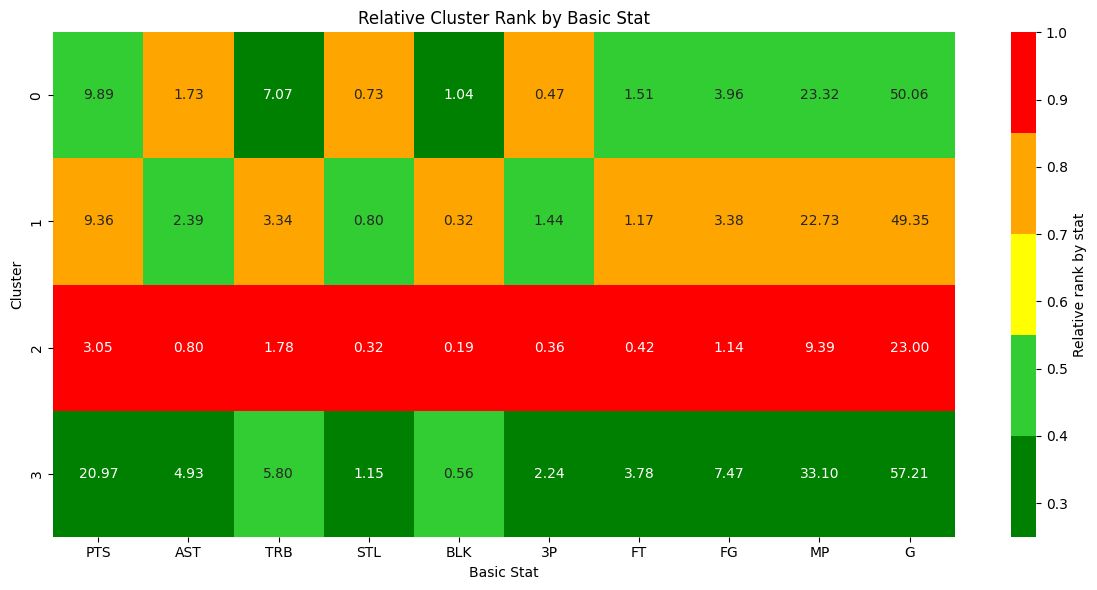

In [213]:
# K-means Clustering on player_basic dataset
qualified_players_basic = player_model_basic.copy()
qualified_features_basic = qualified_players_basic[numeric_cols_basic].fillna(qualified_players_basic[numeric_cols_basic].median())
qualified_scaled_basic = scaler_basic.fit_transform(qualified_features_basic)

kmeans_basic = KMeans(n_clusters=4, random_state=42, n_init=10)
qualified_players_basic["cluster"] = kmeans_basic.fit_predict(qualified_scaled_basic)

print(qualified_players_basic["cluster"].value_counts().sort_index())
print("silhouette score:", round(silhouette_score(qualified_scaled_basic, qualified_players_basic["cluster"]), 3))

cluster_means_basic_kmeans = (
    pd.concat(
        [qualified_players_basic[numeric_cols_basic].reset_index(drop=True), qualified_players_basic["cluster"].reset_index(drop=True)],
        axis=1,
    )
    .groupby("cluster")
    .mean()
)

# Display 10 players for each cluster, along with mean stats for each cluster
for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(qualified_players_basic[qualified_players_basic['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_basic_kmeans.loc[cluster])

# Display feature importance for KMeans clusters using heatmap,
# with colors scaled relative to each stat column
ranked_basic = cluster_means_basic_kmeans.rank(axis=0, method="average", ascending=False)
ranked_norm_basic = ranked_basic / ranked_basic.max()

plt.figure(figsize=(12, 6))
rank_colors = ListedColormap(["green", "limegreen", "yellow", "orange", "red"])
sns.heatmap(
    ranked_norm_basic,
    annot=cluster_means_basic_kmeans.round(2),
    fmt=".2f",
    cmap=rank_colors,
    cbar_kws={"label": "Relative rank by stat"}
)
plt.title("Relative Cluster Rank by Basic Stat")
plt.xlabel("Basic Stat")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### K-means Clustering (Advanced Stats)

cluster
0    141
1    203
2    105
3    209
Name: count, dtype: int64
silhouette score: 0.1

Cluster 0 players:
                 Player Team Pos
12          Ivica Zubac  LAC   C
37          Rudy Gobert  MIN   C
42        Jarrett Allen  CLE   C
65         Myles Turner  IND   C
90       Onyeka Okongwu  ATL   C
93          Jalen Duren  DET   C
109          Yves Missi  NOP   C
123         Nic Claxton  BRK   C
138     P.J. Washington  DAL  PF
154  Wendell Carter Jr.  ORL   C

Cluster 0 mean stats:
PER     16.736170
TS%      0.601621
3PAr     0.180964
FTr      0.321307
ORB%    11.723404
DRB%    22.712057
TRB%    17.219858
AST%    10.364539
STL%     1.451064
BLK%     3.790780
TOV%    13.807857
USG%    16.854610
OWS      1.088652
DWS      0.962411
Age     25.652482
Name: 0, dtype: float64

Cluster 1 players:
                      Player Team Pos
0              Mikal Bridges  NYK  SF
14           Jaden McDaniels  MIN  PF
15             Keegan Murray  SAC  PF
18               Zach LaVine  SAC  S

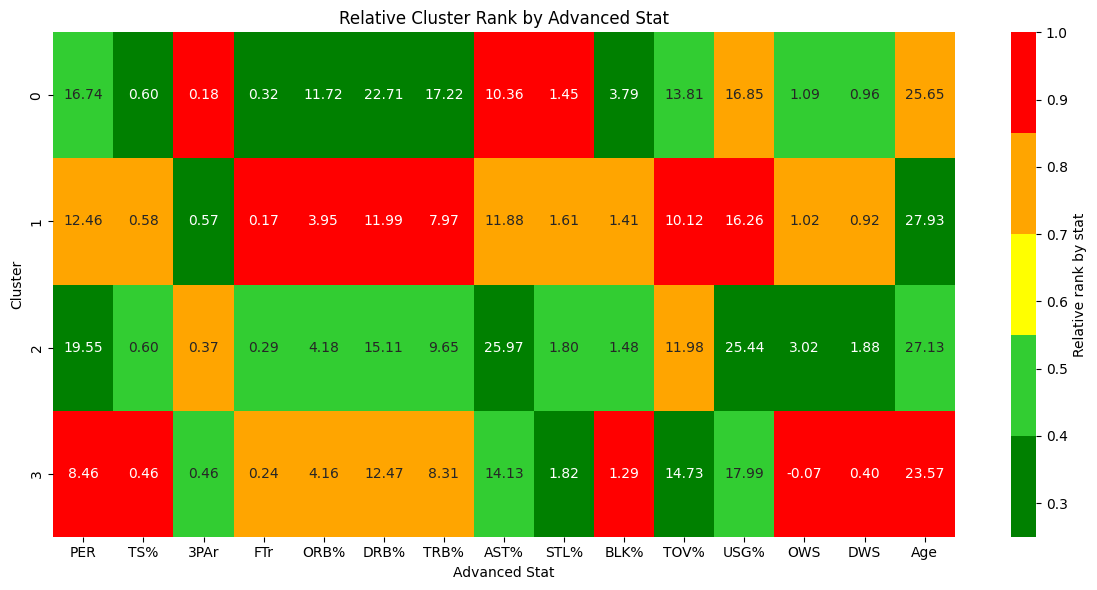

In [214]:
# K-means Clustering on player_advanced dataset
qualified_players_adv = player_model_adv.copy()
qualified_features_adv = qualified_players_adv[numeric_cols_adv].fillna(qualified_players_adv[numeric_cols_adv].median())
qualified_scaled_adv = scaler_adv.fit_transform(qualified_features_adv)

kmeans_adv = KMeans(n_clusters=4, random_state=42, n_init=10)
qualified_players_adv["cluster"] = kmeans_adv.fit_predict(qualified_scaled_adv)

print(qualified_players_adv["cluster"].value_counts().sort_index())
print("silhouette score:", round(silhouette_score(qualified_scaled_adv, qualified_players_adv["cluster"]), 3))

cluster_means_adv_kmeans = (
    pd.concat(
        [qualified_players_adv[numeric_cols_adv].reset_index(drop=True), qualified_players_adv["cluster"].reset_index(drop=True)],
        axis=1,
    )
    .groupby("cluster")
    .mean()
)

# Display 10 players for each cluster, along with mean stats for each cluster
for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(qualified_players_adv[qualified_players_adv['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_adv_kmeans.loc[cluster])

# Display feature importance for KMeans clusters using heatmap,
# with colors scaled relative to each stat column
ranked_adv = cluster_means_adv_kmeans.rank(axis=0, method="average", ascending=False)
ranked_norm_adv = ranked_adv / ranked_adv.max()

plt.figure(figsize=(12, 6))
rank_colors = ListedColormap(["green", "limegreen", "yellow", "orange", "red"])
sns.heatmap(
    ranked_norm_adv,
    annot=cluster_means_adv_kmeans.round(2),
    fmt=".2f",
    cmap=rank_colors,
    cbar_kws={"label": "Relative rank by stat"}
)
plt.title("Relative Cluster Rank by Advanced Stat")
plt.xlabel("Advanced Stat")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

After running hierarchal clustering, lots of new information can be deciphered. First, we can immediately guess at some of the defining features of each cluster. 